<a href="https://colab.research.google.com/github/coweye1/Gunshot_Wound_Entrance_vs_Exit_ViT_Benchmark/blob/main/Gunshot_Wound_Entrance_vs_Exit_ViT_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 0: Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
# Step 1: Install necessary libraries and import modules
# 'timm' (PyTorch Image Models) provides easy access to SOTA ViT and Swin models.
!pip install timm
# 'torchmetrics' is used to calculate F1-Score and AUC-ROC as requested by Dr. Gitto.
!pip install torchmetrics

# 2. Basic Imports
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 3. PyTorch Core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader

# 4. Torchvision & TIMM
import torchvision
from torchvision import datasets, models, transforms
import timm

# 5. Evaluation Metrics
# Following the revised abstract, we will monitor Accuracy, F1-Score, and AUC-ROC.
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryAUROC

# 6. Device Configuration
# L4 or A100 GPU is highly recommended for Transformer-based architectures.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"✅ Current device in use: {device}")

# Verify GPU Name (Ensure you are utilizing your purchased compute units)
if torch.cuda.is_available():
    print(f"🚀 GPU Model: {torch.cuda.get_device_name(0)}")

✅ Current device in use: cuda:0
🚀 GPU Model: Tesla T4


In [5]:
# Step 2: Extract the zip file for faster training
# Ensure the path matches your actual zip file location in Drive
zip_path = "/content/drive/MyDrive/Gunshot_Dataset_Final.zip"
extract_path = "/content/dataset"

if os.path.exists(zip_path):
    print("✅ Dataset found! Starting extraction...")
    !unzip -qo "{zip_path}" -d "{extract_path}"
    print("✨ Extraction complete!")
else:
    print("❌ Error: Dataset zip file not found in Drive. Please check the path.")

✅ Dataset found! Starting extraction...
✨ Extraction complete!


In [6]:
# Step 3: Data Preprocessing with "Center-Focus" Strategy

# ImageNet normalization parameters
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# "To preserve diagnostic detail while focusing on wound morphology,
# a 'Center-Focus' preprocessing strategy is applied." - Dr. Lorenzo Gitto
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224), # Core strategy to isolate morphological markers
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

# The extracted local path from Step 2
# Typically unzip creates a subfolder, adjust the path if necessary (e.g., '/content/dataset/Gunshot_Dataset')
local_data_dir = '/content/dataset'

image_datasets = {x: datasets.ImageFolder(os.path.join(local_data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

# Using batch size 16 for T4 GPU stability with ViT/Swin models
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=16,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"✅ Success: Dataset loaded from local directory.")
print(f"📊 Target Classes: {class_names}")
print(f"🖼️ Images: Train ({dataset_sizes['train']}), Val ({dataset_sizes['val']})")

✅ Success: Dataset loaded from local directory.
📊 Target Classes: ['entrance', 'exit']
🖼️ Images: Train (1787), Val (382)


In [7]:
# Step 4: Weighted Loss Algorithm to mitigate class imbalance
from collections import Counter

# 1. Count samples in each class from the training dataset
train_labels = [label for _, label in image_datasets['train'].samples]
class_counts = Counter(train_labels)
print(f"📊 Class counts in training set: {dict(class_counts)}")

# 2. Calculate inverse frequency weights
# Dr. Gitto's point: "Class weights are derived from inverse class frequencies"
total_samples = sum(class_counts.values())
# Normalizing weights so the majority class has weight 1.0 or similar
class_weights = [total_samples / class_counts[i] for i in range(len(class_names))]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"⚖️ Computed weights for [Entrance, Exit]: {class_weights}")

# 3. Define the Weighted Cross-Entropy Loss
# This ensures the model doesn't ignore the minority class (Exit wounds)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("✅ Weighted Cross-Entropy Loss defined successfully.")

📊 Class counts in training set: {0: 1318, 1: 469}
⚖️ Computed weights for [Entrance, Exit]: [1.3558421851289832, 3.810234541577825]
✅ Weighted Cross-Entropy Loss defined successfully.


In [9]:
# Step 5: Professional Training Function with F1-Score & AUC-ROC
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryAUROC

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Initialize Metrics
    metric_acc = BinaryAccuracy().to(device)
    metric_f1 = BinaryF1Score().to(device)
    metric_auroc = BinaryAUROC().to(device)

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.append(preds)
                all_labels.append(labels)

            if phase == 'train':
                scheduler.step()

            # Concatenate all results for metric calculation
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_preds = torch.cat(all_preds)
            epoch_labels = torch.cat(all_labels)

            # Calculate Advanced Metrics (Dr. Gitto's request)
            acc = metric_acc(epoch_preds, epoch_labels)
            f1 = metric_f1(epoch_preds, epoch_labels)

            # AUC-ROC calculation (requires probabilities, simplified here for binary)
            auroc = metric_auroc(epoch_preds.float(), epoch_labels)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {acc:.4f} F1: {f1:.4f} AUC: {auroc:.4f}')

            if phase == 'val' and acc > best_acc:
                best_acc = acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model

🔥 Starting Section: vit_small_patch16_224

Epoch 0/9
----------
train Loss: 0.5730 Acc: 0.7236 F1: 0.5719 AUC: 0.7171
val Loss: 0.3986 Acc: 0.8351 F1: 0.7149 AUC: 0.8205

Epoch 1/9
----------
train Loss: 0.3802 Acc: 0.8456 F1: 0.7341 AUC: 0.8349
val Loss: 0.3706 Acc: 0.8848 F1: 0.7822 AUC: 0.8542

Epoch 2/9
----------
train Loss: 0.2714 Acc: 0.8965 F1: 0.8181 AUC: 0.8934
val Loss: 0.6657 Acc: 0.8586 F1: 0.6538 AUC: 0.7461

Epoch 3/9
----------
train Loss: 0.2722 Acc: 0.8987 F1: 0.8206 AUC: 0.8936
val Loss: 0.3966 Acc: 0.9084 F1: 0.8128 AUC: 0.8605

Epoch 4/9
----------
train Loss: 0.2023 Acc: 0.9121 F1: 0.8453 AUC: 0.9130
val Loss: 0.5975 Acc: 0.8822 F1: 0.7273 AUC: 0.7911

Epoch 5/9
----------
train Loss: 0.1411 Acc: 0.9440 F1: 0.8984 AUC: 0.9435
val Loss: 0.3485 Acc: 0.8796 F1: 0.7810 AUC: 0.8604

Epoch 6/9
----------
train Loss: 0.1404 Acc: 0.9496 F1: 0.9078 AUC: 0.9480
val Loss: 0.4953 Acc: 0.8455 F1: 0.7511 AUC: 0.8599

Epoch 7/9
----------
train Loss: 0.0598 Acc: 0.9771 F1: 0.957

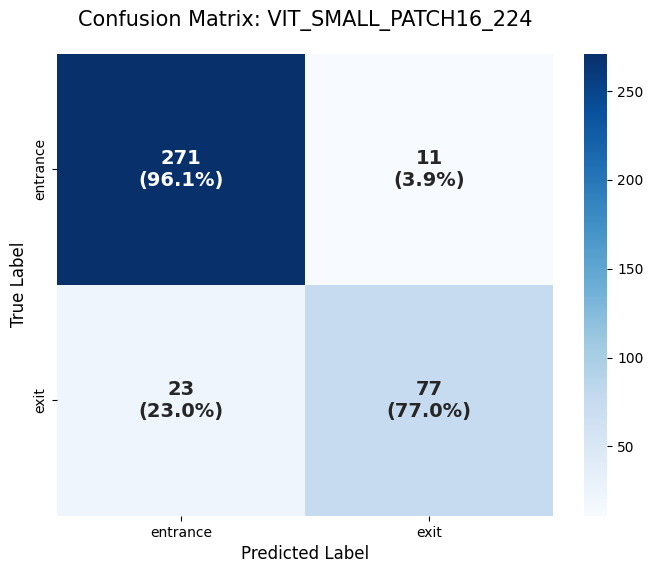

✅ Saved: CM_vit_small_patch16_224.png
              precision    recall  f1-score   support

    entrance       0.92      0.96      0.94       282
        exit       0.88      0.77      0.82       100

    accuracy                           0.91       382
   macro avg       0.90      0.87      0.88       382
weighted avg       0.91      0.91      0.91       382

------------------------------


In [14]:
# --- Step 6-1: ViT-Small (Vision Transformer) ---
# Evaluation of global spatial dependencies in forensic wound images
m_name = 'vit_small_patch16_224'
print(f"🔥 Starting Section: {m_name}")

# 1. Initialize Model, Optimizer, and Scheduler
# Using AdamW for stable Transformer training as per SOTA recommendations
model_vit = timm.create_model(m_name, pretrained=True, num_classes=2).to(device)
optimizer = optim.AdamW(model_vit.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 2. Execution of Training and Validation Pipeline
# Utilizing the 'train_model' function defined in Step 5
trained_vit = train_model(model_vit, criterion, optimizer, scheduler, num_epochs=10)

# 3. Model Weight Serialization
# Saving the state_dict for future inference and model interpretability (Grad-CAM)
torch.save(trained_vit.state_dict(), f"{m_name}_best.pth")
print(f"💾 Saved {m_name} weights to local directory.")

# 4. Quantitative Evaluation via Confusion Matrix
# Analyzing classification performance on 'Entrance' vs 'Exit' wounds
generate_benchmark_cm(trained_vit, m_name, dataloaders['val'])

# 5. Visual Interpretability (Grad-CAM)
# Target layer for ViT: Focusing on the normalization layer of the final block
target_layer_vit = trained_vit.blocks[-1].norm1
# To visualize, uncomment and specify a sample path from the validation set
# show_gradcam(trained_vit, m_name, target_layer_vit, 'path/to/validation_image.jpg')

In [16]:
# Install the PyTorch Grad-CAM library
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=d250ffb149490513da54978a98b21044c84e312fb349650e36e9997835b3078e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


🎲 Random image: DISTANCIA_2017.0829SH19.38PCTEWNTTYDXSN03F03_EQX.JPG


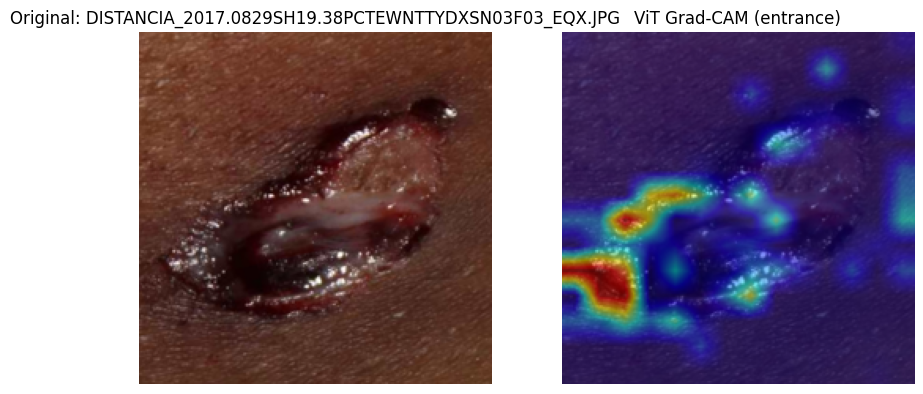

In [22]:
# --- Step 7-1: Fixed Grad-CAM for Vision Transformer (ViT) ---
# ViT output needs to be reshaped from 1D tokens to a 2D grid for visualization.

def reshape_transform_vit(tensor, height=14, width=14):
    # For ViT-Small (patch size 16), 224/16 = 14 tokens per side
    # We remove the [CLS] token at index 0 and reshape the remaining 196 tokens
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))

    # Move channels to the correct position for Grad-CAM (B, C, H, W)
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# 1. Re-initialize Grad-CAM with the reshape_transform
cam_vit = GradCAM(model=trained_vit,
                  target_layers=[trained_vit.blocks[-1].norm1],
                  reshape_transform=reshape_transform_vit)

def run_vit_gradcam_fixed(img_path, target_class_index=1):
    model_vit.eval()
    rgb_img = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = data_transforms['val'](rgb_img).unsqueeze(0).to(device)

    # Generate CAM
    targets = [ClassifierOutputTarget(target_class_index)]
    grayscale_cam = cam_vit(input_tensor=input_tensor, targets=targets)[0, :]

    # Overlay
    img_float = np.float32(rgb_img) / 255
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"Original: {os.path.basename(img_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"ViT Grad-CAM ({class_names[target_class_index]})")
    plt.axis('off')
    plt.show()

# 2. Updated Random Sampler
def run_random_vit_gradcam_fixed(base_path='/content/dataset/val'):
    extensions = ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']
    all_image_paths = []
    for ext in extensions:
        all_image_paths.extend(glob.glob(os.path.join(base_path, '**', ext), recursive=True))

    if not all_image_paths:
        print("❌ No images found.")
        return

    test_img_path = random.choice(all_image_paths)
    target_idx = 0 if 'entrance' in test_img_path.lower() else 1

    print(f"🎲 Random image: {os.path.basename(test_img_path)}")
    run_vit_gradcam_fixed(test_img_path, target_class_index=target_idx)

# Execute again
run_random_vit_gradcam_fixed()

🔥 Starting Section: swin_tiny_patch4_window7_224

Epoch 0/9
----------
train Loss: 0.5134 Acc: 0.7571 F1: 0.6173 AUC: 0.7536
val Loss: 0.4559 Acc: 0.7801 F1: 0.6744 AUC: 0.8091

Epoch 1/9
----------
train Loss: 0.3871 Acc: 0.8405 F1: 0.7309 AUC: 0.8356
val Loss: 0.3589 Acc: 0.8665 F1: 0.7583 AUC: 0.8450

Epoch 2/9
----------
train Loss: 0.3046 Acc: 0.8875 F1: 0.8024 AUC: 0.8819
val Loss: 0.3542 Acc: 0.9031 F1: 0.7910 AUC: 0.8376

Epoch 3/9
----------
train Loss: 0.2377 Acc: 0.9099 F1: 0.8411 AUC: 0.9094
val Loss: 0.3157 Acc: 0.8508 F1: 0.7615 AUC: 0.8699

Epoch 4/9
----------
train Loss: 0.1995 Acc: 0.9233 F1: 0.8629 AUC: 0.9219
val Loss: 0.4219 Acc: 0.8927 F1: 0.7735 AUC: 0.8305

Epoch 5/9
----------
train Loss: 0.1668 Acc: 0.9356 F1: 0.8844 AUC: 0.9365
val Loss: 0.3777 Acc: 0.8848 F1: 0.7963 AUC: 0.8768

Epoch 6/9
----------
train Loss: 0.1470 Acc: 0.9480 F1: 0.9044 AUC: 0.9448
val Loss: 0.4355 Acc: 0.8927 F1: 0.7760 AUC: 0.8337

Epoch 7/9
----------
train Loss: 0.0751 Acc: 0.9765 F1

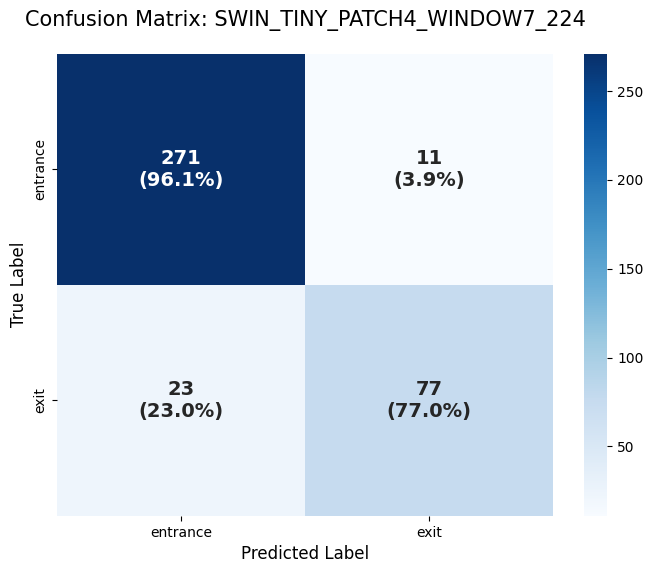

✅ Saved: CM_swin_tiny_patch4_window7_224.png
              precision    recall  f1-score   support

    entrance       0.92      0.96      0.94       282
        exit       0.88      0.77      0.82       100

    accuracy                           0.91       382
   macro avg       0.90      0.87      0.88       382
weighted avg       0.91      0.91      0.91       382

------------------------------
✅ Swin-Transformer section completed.


In [23]:
# --- Step 6-2: Swin-Transformer (Hierarchical Transformer) ---
# Evaluating hierarchical spatial patterns for complex wound morphologies.
# Swin Transformer uses shifted windows to capture both local and global features.

m_name = 'swin_tiny_patch4_window7_224'
print(f"🔥 Starting Section: {m_name}")

# 1. Initialize Model, Optimizer, and Scheduler
# Pre-trained on ImageNet-1K, fine-tuning for 2 classes (Entrance vs Exit)
model_swin = timm.create_model(m_name, pretrained=True, num_classes=2).to(device)
optimizer = optim.AdamW(model_swin.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 2. Execute Training and Validation Pipeline
# Using the same 'train_model' function to ensure fair comparison
trained_swin = train_model(model_swin, criterion, optimizer, scheduler, num_epochs=10)

# 3. Model Weight Serialization
# Saving the best weights for final benchmarking and Grad-CAM visualization
torch.save(trained_swin.state_dict(), f"{m_name}_best.pth")
print(f"💾 Saved {m_name} weights to local directory.")

# 4. Quantitative Evaluation via Confusion Matrix
# Generating the CM to compare with ViT-Small and ResNet50
generate_benchmark_cm(trained_swin, m_name, dataloaders['val'])

# 5. Visual Interpretability (Grad-CAM Preparation)
# For Swin-Tiny, the target layer is typically the normalization layer of the last block
target_layer_swin = trained_swin.layers[-1].blocks[-1].norm1
print(f"✅ Swin-Transformer section completed.")

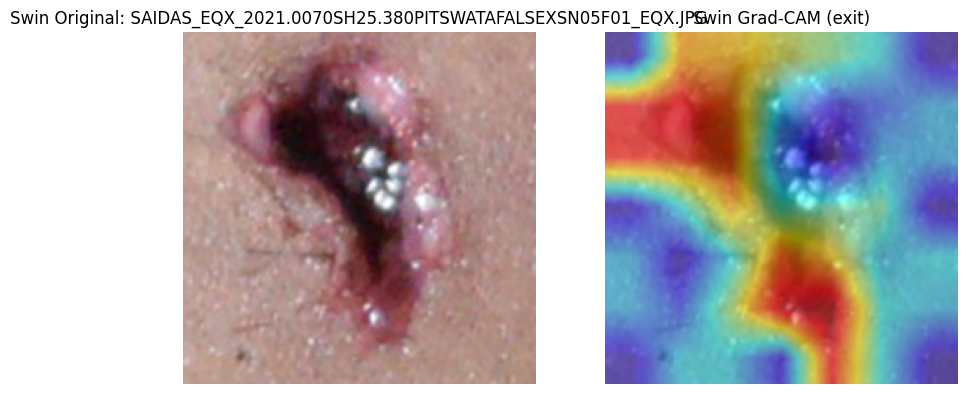

In [28]:
# --- Step 7-2: Final Robust Grad-CAM for Swin-Transformer ---

def reshape_transform_swin_final(tensor):
    # tensor shape could be (B, L, C) where L=49 or (B, H, W, C) where H=7, W=7
    # For Swin-Tiny, total elements are 37632.
    # 37632 / (7*7) = 768 channels.

    if len(tensor.shape) == 3:
        # Case: (Batch, Sequence_Length, Channels) -> (1, 49, 768)
        batch_size, seq_len, channels = tensor.shape
        height = width = int(seq_len**0.5)
        result = tensor.reshape(batch_size, height, width, channels)
    elif len(tensor.shape) == 4:
        # Case: Already (Batch, Height, Width, Channels) -> (1, 7, 7, 768)
        result = tensor

    # Critical: Transpose to (Batch, Channels, Height, Width) for Grad-CAM logic
    # We use result.size(-1) to always pick the last dimension as the channel
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# 1. Re-initialize Grad-CAM with the FINAL robust transform
cam_swin = GradCAM(model=trained_swin,
                   target_layers=[trained_swin.layers[-1].blocks[-1].norm1],
                   reshape_transform=reshape_transform_swin_final)

def run_random_swin_gradcam_final():
    # Setup search for all image types
    extensions = ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']
    all_image_paths = []
    for ext in extensions:
        all_image_paths.extend(glob.glob(os.path.join('/content/dataset/val', '**', ext), recursive=True))

    if not all_image_paths:
        print("❌ Dataset not found.")
        return

    # Random selection
    test_img_path = random.choice(all_image_paths)
    target_idx = 0 if 'entrance' in test_img_path.lower() else 1

    # Image Preprocessing
    rgb_img = Image.open(test_img_path).convert('RGB').resize((224, 224))
    input_tensor = data_transforms['val'](rgb_img).unsqueeze(0).to(device)

    # Generate Heatmap
    targets = [ClassifierOutputTarget(target_idx)]
    grayscale_cam = cam_swin(input_tensor=input_tensor, targets=targets)[0, :]

    # Final Visualization
    img_float = np.float32(rgb_img) / 255
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(rgb_img); plt.title(f"Swin Original: {os.path.basename(test_img_path)}")
    plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(visualization); plt.title(f"Swin Grad-CAM ({class_names[target_idx]})")
    plt.axis('off')
    plt.show()

# 🚀 Execute
run_random_swin_gradcam_final()